In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
# Install dependencies first:
# pip install kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "Sample - Superstore.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "vivek468/superstore-dataset-final",
    file_path,
    pandas_kwargs={"encoding": "latin1"}
)

print("First 5 records:")
print(df.head())

/tmp/ipykernel_1238/1002413967.py:9: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'superstore-dataset-final' dataset.
First 5 records:
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ... 

In [3]:
df.shape

(9994, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [6]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [7]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [8]:
df = df.dropna()
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [11]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month Name
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,November
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,November
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,June
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,October
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,October


In [12]:
total_sales = df["Sales"].sum()
total_sales

np.float64(2297200.8603000003)

In [13]:
total_profit = df["Profit"].sum()
total_profit

np.float64(286397.0217)

In [14]:
total_quantity = df["Quantity"].sum()
total_quantity

np.int64(37873)

In [15]:
sales_by_category = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
sales_by_category

,Sales
Category,
Technology,836154.0330
Furniture,741999.7953
Office Supplies,719047.0320


In [16]:
profit_by_category = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)
profit_by_category

,Profit
Category,
Technology,145454.9481
Office Supplies,122490.8008
Furniture,18451.2728


In [17]:
sales_by_region = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
sales_by_region

,Sales
Region,
West,725457.8245
East,678781.2400
Central,501239.8908
South,391721.9050


In [18]:
profit_by_region = df.groupby("Region")["Profit"].sum().sort_values(ascending=False)
profit_by_region

,Profit
Region,
West,108418.4489
East,91522.7800
South,46749.4303
Central,39706.3625


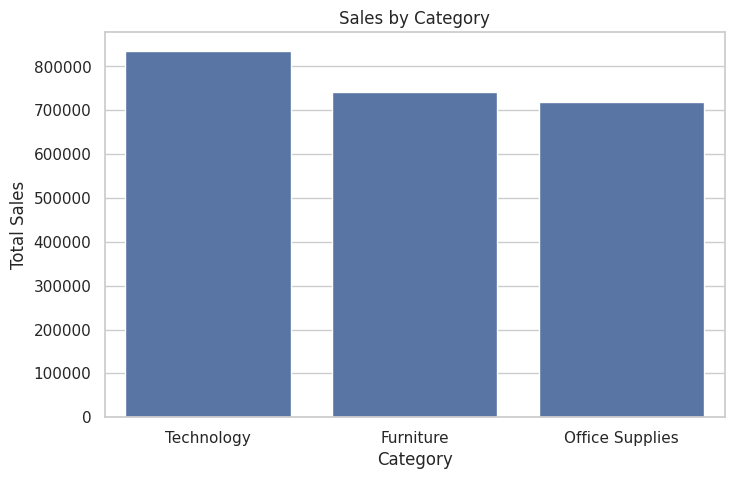

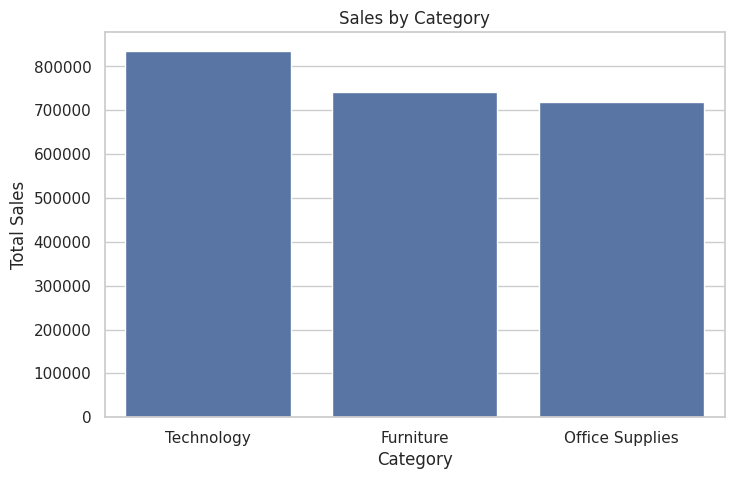

In [20]:
Zplt.figure(figsize=(8,5))
sns.barplot(x=sales_by_category.index, y=sales_by_category.values)
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

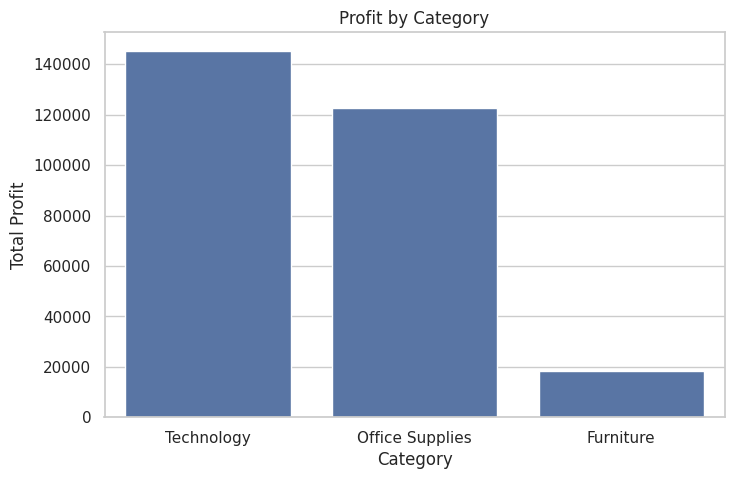

In [30]:
plt.figure(figsize=(8,5))
sns.barplot(x=profit_by_category.index, y=profit_by_category.values)
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.show()

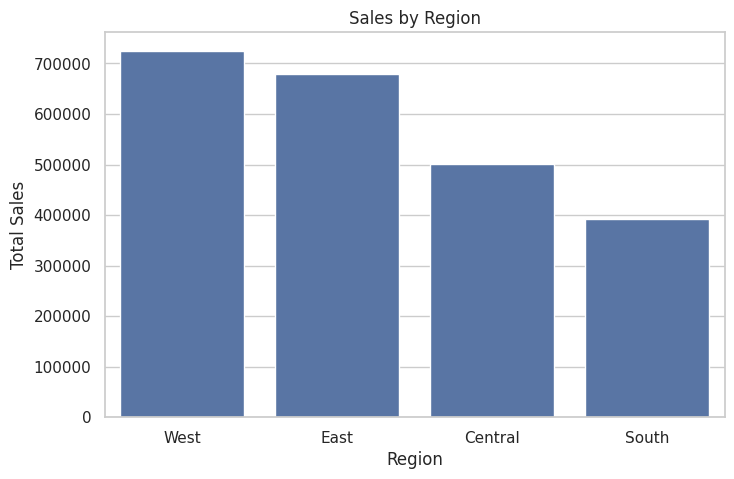

In [29]:
plt.figure(figsize=(8,5))
sns.barplot(x=sales_by_region.index, y=sales_by_region.values)
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

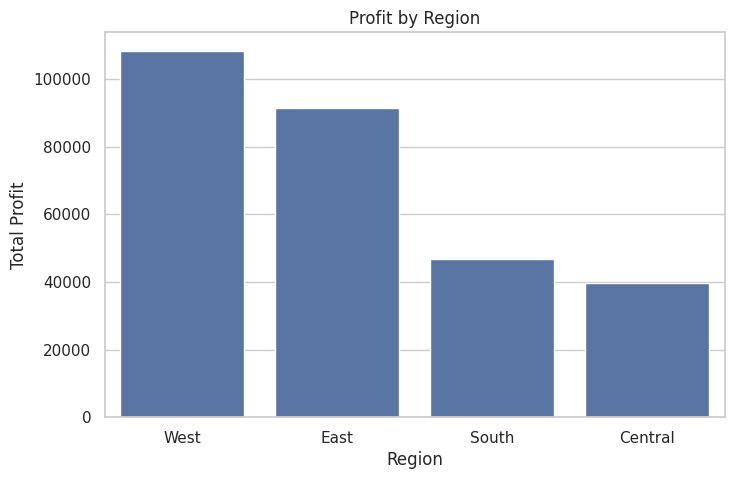

In [28]:
plt.figure(figsize=(8,5))
sns.barplot(x=profit_by_region.index, y=profit_by_region.values)
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.show()

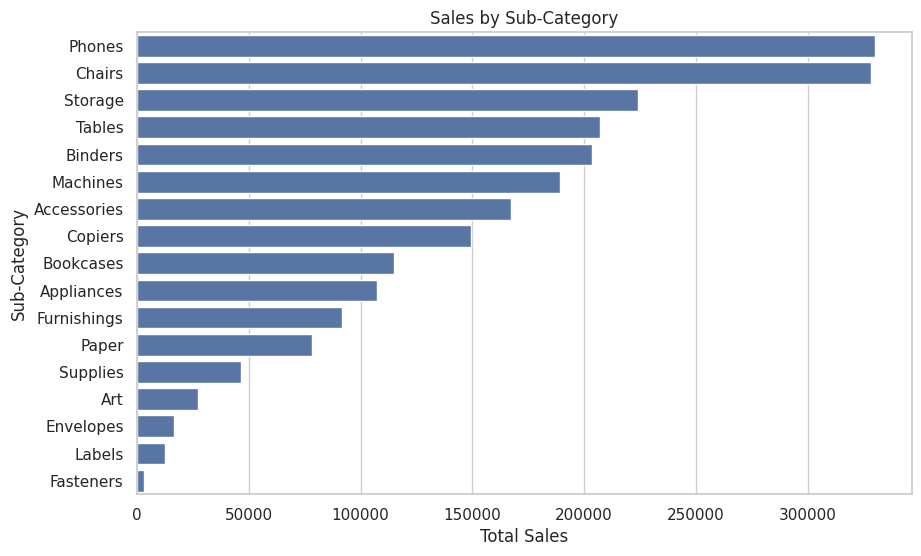

In [27]:
sales_by_subcategory = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=sales_by_subcategory.values, y=sales_by_subcategory.index)
plt.title("Sales by Sub-Category")
plt.xlabel("Total Sales")
plt.ylabel("Sub-Category")
plt.show()

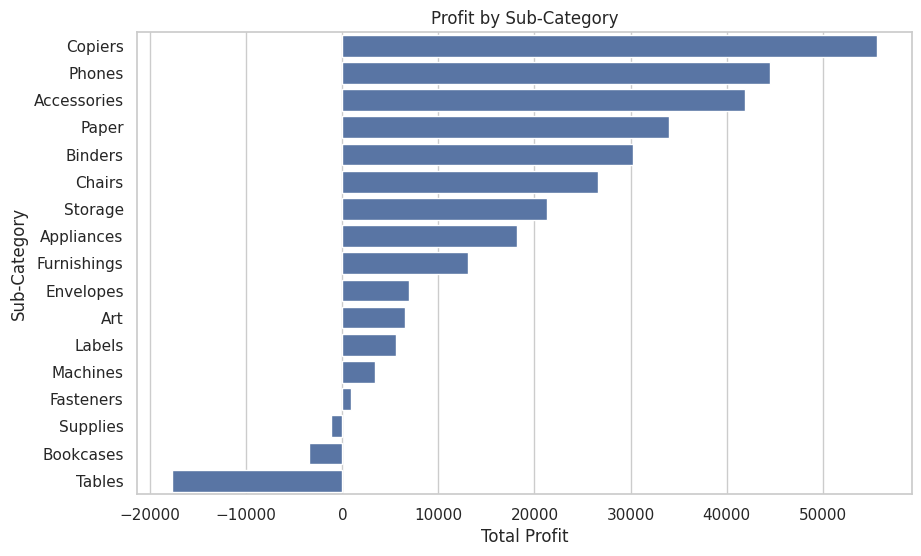

In [26]:
profit_by_subcategory = df.groupby("Sub-Category")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=profit_by_subcategory.values, y=profit_by_subcategory.index)
plt.title("Profit by Sub-Category")
plt.xlabel("Total Profit")
plt.ylabel("Sub-Category")
plt.show()

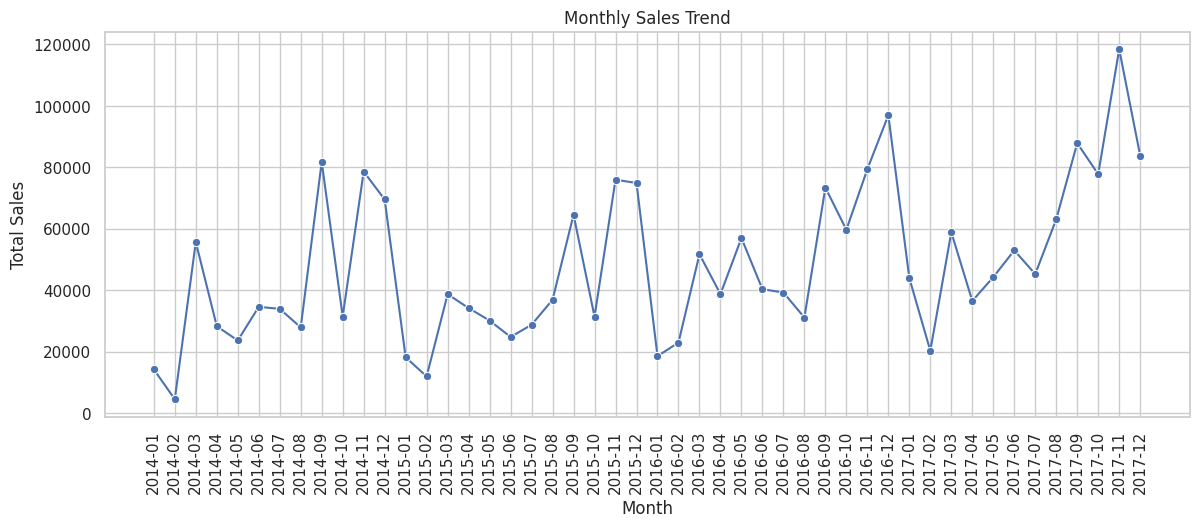

In [25]:
monthly_sales = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()
monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(14,5))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.show()

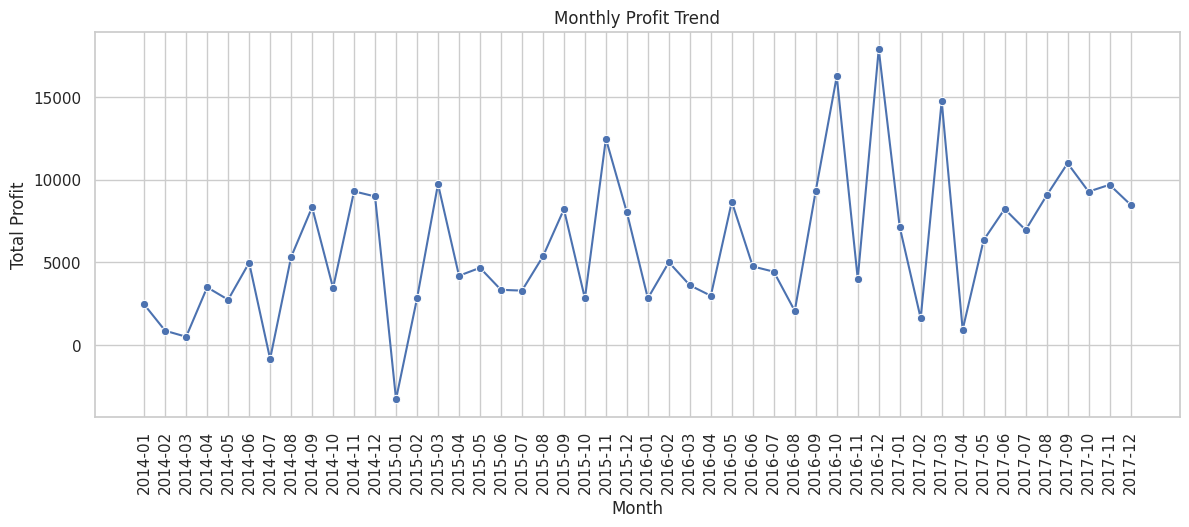

In [24]:
monthly_profit = df.groupby(df["Order Date"].dt.to_period("M"))["Profit"].sum()
monthly_profit.index = monthly_profit.index.astype(str)

plt.figure(figsize=(14,5))
sns.lineplot(x=monthly_profit.index, y=monthly_profit.values, marker="o")
plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Total Profit")
plt.xticks(rotation=90)
plt.show()

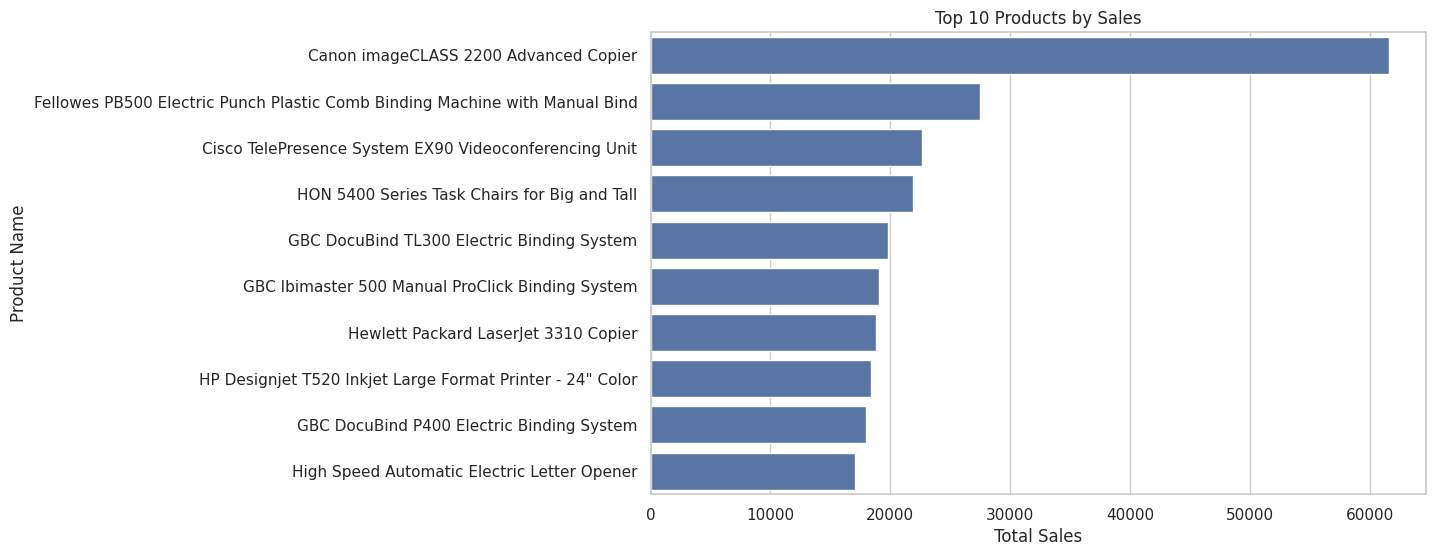

In [23]:
top_products_sales = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_products_sales.values, y=top_products_sales.index)
plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")
plt.show()

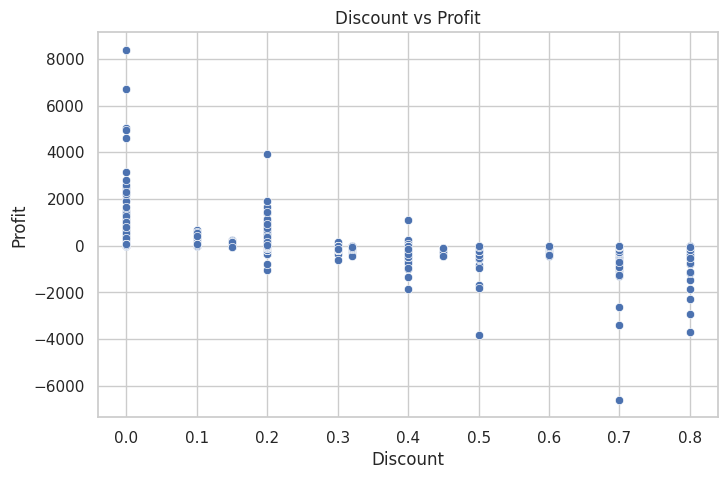

In [22]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Discount", y="Profit")
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

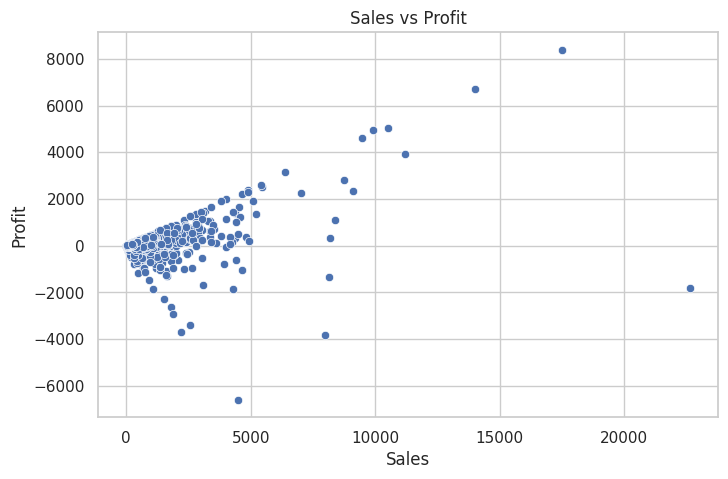

In [21]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Sales", y="Profit")
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

In [31]:
print("===== Final Analysis Summary =====")

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Quantity Sold:", total_quantity)

print("\nBest Category by Sales:")
print(sales_by_category.head(1))

print("\nBest Category by Profit:")
print(profit_by_category.head(1))

print("\nBest Region by Sales:")
print(sales_by_region.head(1))

print("\nBest Region by Profit:")
print(profit_by_region.head(1))

print("\nTop Product by Sales:")
print(top_products_sales.head(1))

print("\nBest Sub-Category by Sales:")
print(sales_by_subcategory.head(1))

print("\nBest Sub-Category by Profit:")
print(profit_by_subcategory.head(1))

===== Final Analysis Summary =====
Total Sales: 2297200.86
Total Profit: 286397.02
Total Quantity Sold: 37873

Best Category by Sales:
Category
Technology    836154.033
Name: Sales, dtype: float64

Best Category by Profit:
Category
Technology    145454.9481
Name: Profit, dtype: float64

Best Region by Sales:
Region
West    725457.8245
Name: Sales, dtype: float64

Best Region by Profit:
Region
West    108418.4489
Name: Profit, dtype: float64

Top Product by Sales:
Product Name
Canon imageCLASS 2200 Advanced Copier    61599.824
Name: Sales, dtype: float64

Best Sub-Category by Sales:
Sub-Category
Phones    330007.054
Name: Sales, dtype: float64

Best Sub-Category by Profit:
Sub-Category
Copiers    55617.8249
Name: Profit, dtype: float64


In [33]:
loss_orders = df[df["Profit"] < 0]

loss_by_subcategory = loss_orders.groupby("Sub-Category")["Profit"].sum().sort_values()

loss_by_subcategory

,Profit
Sub-Category,
Binders,-38510.4964
Tables,-32412.1483
Machines,-30118.6682
Bookcases,-12152.2060
Chairs,-9880.8413
Appliances,-8629.6412
Phones,-7530.6235
Furnishings,-6490.9134
Storage,-6426.3038


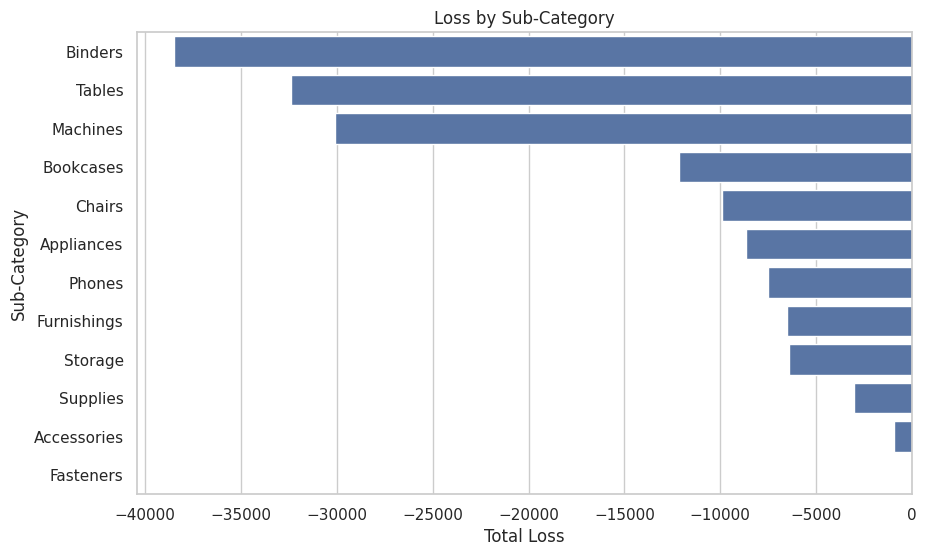

In [34]:
plt.figure(figsize=(10,6))
sns.barplot(x=loss_by_subcategory.values, y=loss_by_subcategory.index)
plt.title("Loss by Sub-Category")
plt.xlabel("Total Loss")
plt.ylabel("Sub-Category")
plt.show()

## Final Insights

1. The dataset contains 9,994 rows and 21 original columns, including sales, profit, products, customers, categories, regions, and order dates.

2. The total sales amount is around 2.29 million, while the total profit is around 286 thousand.

3. Technology is the highest-performing category in both sales and profit, which means it is the strongest business category.

4. The West region achieved the highest sales and the highest profit, making it the best-performing region.

5. Phones, Chairs, and Storage are among the strongest sub-categories by sales.

6. Copiers generated the highest profit among sub-categories, while Tables and Bookcases caused losses.

7. The monthly sales trend shows that sales increased strongly in several months, especially near the end of the year.

8. The discount vs profit chart shows that high discounts can reduce profit and sometimes lead to losses.

9. The company should focus more on profitable categories like Technology and review loss-making sub-categories such as Tables and Bookcases.

## Conclusion

This project completed Exploratory Data Analysis and Data Visualization on the Superstore sales dataset.  
The analysis helped identify the best-performing categories, regions, products, and sub-categories.  
The visualizations also revealed important business patterns related to sales trends, profitability, and discount impact.

This project satisfies:

- Task 2: Exploratory Data Analysis
- Task 3: Data Visualization